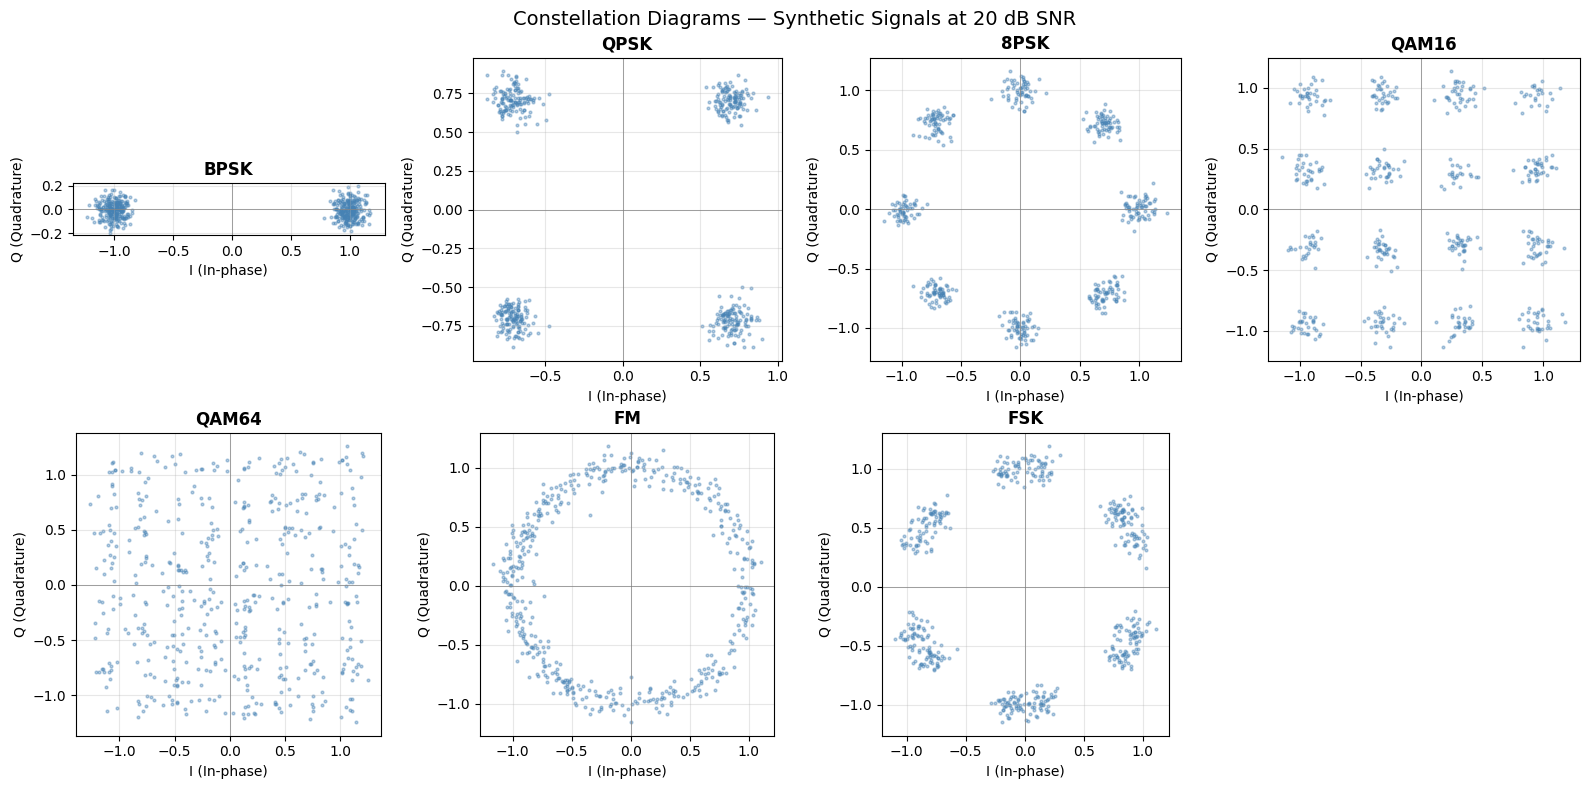

In [3]:
# notebooks/01_synth_verification.ipynb

import numpy as np
import matplotlib.pyplot as plt
import sys
import os
sys.path.insert(0, os.path.abspath(".."))
from dsp.synth import (generate_bpsk, generate_qpsk, generate_8psk,
                        generate_qam, generate_fm, generate_fsk)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("Constellation Diagrams — Synthetic Signals at 20 dB SNR",
             fontsize=14)

configs = [
    ("BPSK",  generate_bpsk(500, sps=8, snr_db=20)),
    ("QPSK",  generate_qpsk(500, sps=8, snr_db=20)),
    ("8PSK",  generate_8psk(500, sps=8, snr_db=20)),
    ("QAM16", generate_qam(500, 16, sps=8, snr_db=20)),
    ("QAM64", generate_qam(500, 64, sps=8, snr_db=20)),
    ("FM",    generate_fm(4000, snr_db=20)),
    ("FSK",   generate_fsk(500, sps=8, snr_db=20)),
]

for ax, (name, sig) in zip(axes.flat, configs):
    # Sample one point per symbol (every sps-th sample) for digital mods
    # For FM/FSK, sample every 8th point
    samples = sig[::8]
    ax.scatter(samples.real, samples.imag, s=4, alpha=0.4, color="steelblue")
    ax.set_title(name, fontsize=12, fontweight="bold")
    ax.set_xlabel("I (In-phase)")
    ax.set_ylabel("Q (Quadrature)")
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.axvline(0, color='gray', linewidth=0.5)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

axes.flat[-1].set_visible(False)  # hide 8th subplot
plt.tight_layout()
plt.show()